<a href="https://colab.research.google.com/github/thanglechien/DataPreprocess/blob/main/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA) with Avocado Dataset

This notebook demonstrates **Exploratory Data Analysis (EDA)** on the **Avocado** dataset provided in the CSV format. We are going to:

1. Load and inspect data
2. Check if missing values exit
3. Explore potential outliers
4. Visualize distributions of numeric/categorical features
5. Examine relationships between features (e.g., correlation, grouping)
6. Create informative data visualizations (Seaborn + Matplotlib)

## 1. Installation and Imports

In [ ]:
# install pandas, matplotlib, and seaborn
import sys
!{sys.executable} -m pip install --quiet seaborn matplotlib pandas

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

%matplotlib inline
# set display options:
# Show all columns (no column truncation)
pd.set_option('display.max_columns', None)

# (Optional) Don't truncate long text fields in cells
pd.set_option('display.max_colwidth', None)

# Seaborn style
sns.set_style('whitegrid')

## 2. Load the Avocados Dataset

In [ ]:
# connect Google Drive to the Colab Environment & copy the avocado.csv file to my Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/avocado.csv')

In [ ]:
df.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


The DataFrame includes the following columns:
- Unnamed: 0
- Date (the date of the observation)
- AveragePrice (the average price of a single avocado)
- Total Volume (total number of avocados sold)
- 4046 (total number of avocados with PLU 4046 sold)
- 4225 (total number of avocados with PLU 4225 sold)
- 4770 (total number of avocados with PLU 4770 sold)
- Total Bags (total number of all bags of all sizes)
- Small Bags (total number of small bags)
- Large Bags (total number of large bags)
- XLarge Bags(total number of extra large bags)
- type (conventional or organic)
- year (the year)
- region (the city or region of the observation)



### 2.1 Basic Overview
Let's check the **shape**, **info**, and some **summary statistics**.


In [ ]:
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())

Shape: (18249, 14)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB
None


In [ ]:
df.describe(include='all').round(2)

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
count,18249.00,18249,18249.00,18249.00,18249.00,18249.00,18249.00,18249.00,18249.00,18249.00,18249.00,18249,18249.00,18249
unique,NaN,169,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,54
top,NaN,2015-12-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conventional,NaN,Albany
freq,NaN,108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9126,NaN,338
mean,24.23,NaN,1.41,850644.01,293008.42,295154.57,22839.74,239639.20,182194.69,54338.09,3106.43,NaN,2016.15,NaN
std,15.48,NaN,0.40,3453545.36,1264989.08,1204120.40,107464.07,986242.40,746178.51,243965.96,17692.89,NaN,0.94,NaN
min,0.00,NaN,0.44,84.56,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,2015.00,NaN
25%,10.00,NaN,1.10,10838.58,854.07,3008.78,0.00,5088.64,2849.42,127.47,0.00,NaN,2015.00,NaN
50%,24.00,NaN,1.37,107376.76,8645.30,29061.02,184.99,39743.83,26362.82,2647.71,0.00,NaN,2016.00,NaN
75%,38.00,NaN,1.66,432962.29,111020.20,150206.86,6243.42,110783.37,83337.67,22029.25,132.50,NaN,2017.00,NaN


Observations:
- From info(), there is no missing value. Hence, we do not need to handle missing values

- From describe(), max values of Total Volume, 4046, 4225, 4770 appear too large and may be outliers

- The Unamed column seems to be the week in the year that the date belongs, but in revese order.
- The Date column has a Dtype of object, we need to convert it to datetime, so that we can create week and month columns for later time-series analysis if neccessary

- The region column has a large number of unique values (54)

- The type column has two unique values: organic vs conventional avocados

###2.2. Revise the DataFrame

Next steps:
- Drop some columns (Unnamed, Total Bags, Small Bags, Large Bags, and ELarge Bags) to keep only relevant data for this assignment.
- Convert Date column to datatime
- Create 2 new columns: week and month

In [ ]:
# drop columns
df.drop(['Unnamed: 0', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags'], axis=1, inplace=True)

# convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# create week and month columns
df['week'] = df['Date'].dt.isocalendar().week
df['month'] = df['Date'].dt.month

In [ ]:
df.head() #our updated DataFrame

,Date,AveragePrice,Total Volume,4046,4225,4770,type,year,region,week,month
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,conventional,2015,Albany,52,12
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,conventional,2015,Albany,51,12
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,conventional,2015,Albany,50,12
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,conventional,2015,Albany,49,12
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,conventional,2015,Albany,48,11


### 3. Exploring Outliers
- The large maximum values in columns Total Volumne, PLU4046, PLU4225, PLU4770 suggest the need for outlier analysis.
- We will devolop boxplots to examine these features

Text(0.5, 1.0, 'Figure 4: Boxplot of Volume of PLU 4770')

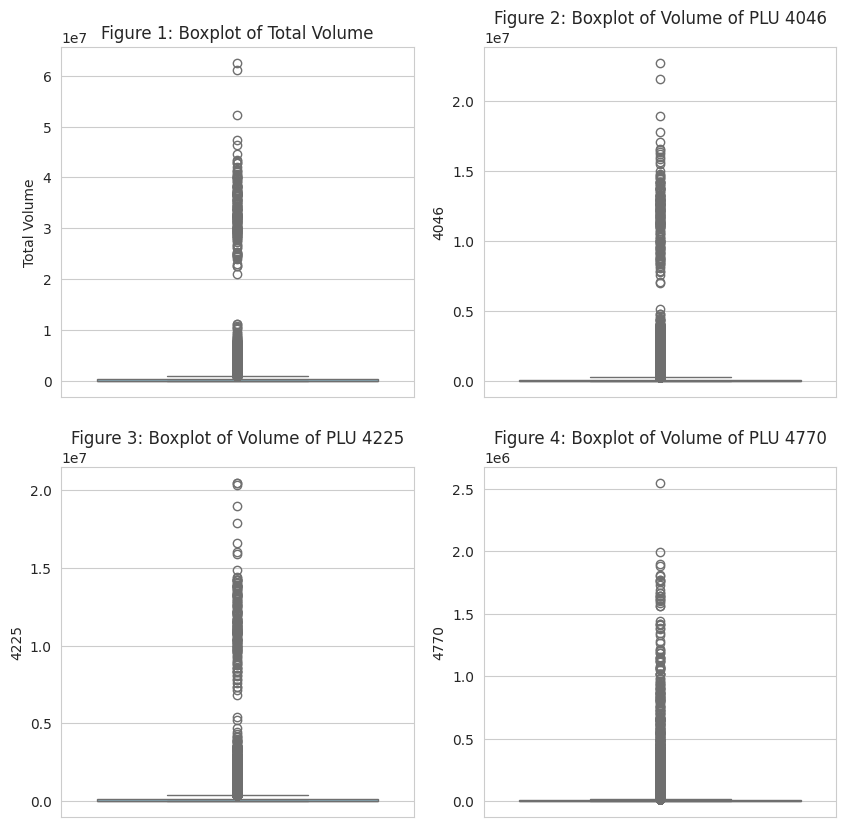

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
sns.boxplot(ax=axes[0][0], data=df, y='Total Volume', color='skyblue')
axes[0][0].set_title('Figure 1: Boxplot of Total Volume')

sns.boxplot(ax=axes[0][1], data=df, y='4046', color='skyblue')
axes[0][1].set_title('Figure 2: Boxplot of Volume of PLU 4046')

sns.boxplot(ax=axes[1][0], data=df, y='4225', color='skyblue')
axes[1][0].set_title('Figure 3: Boxplot of Volume of PLU 4225')

sns.boxplot(ax=axes[1][1], data=df, y='4770', color='skyblue')
axes[1][1].set_title('Figure 4: Boxplot of Volume of PLU 4770')

Observations:
- The boxplots are collapsed into small lines at the bottom, while there are a long upper trails
- The trails appear to be divided into two separate parts, suggesting the data may come from different populations
- We will calculate the z-scores for the Total Volume and explore what values are potentially outliers and what rows contain them

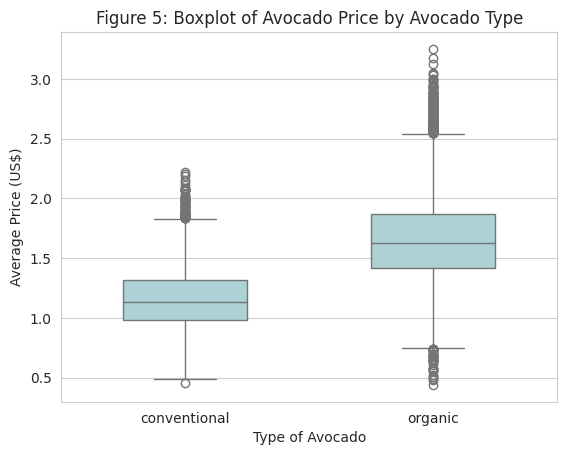

In [ ]:
p = sns.boxplot(data=df, y='AveragePrice', x='type', color='#A5D8DD', width=0.5)
p.set_title('Figure 5: Boxplot of Avocado Price by Avocado Type')
p.set_xlabel('Type of Avocado')
p.set_ylabel('Average Price (US$)')
plt.show()

Observations:
- The boxplots for average price by avocado type shows a clear picture.
- Organic avocados were more expensive than conventional avocados
- There are quite a number of potential price outliers in both product type

Calculate z-scores and identify rows with potential outliers for Total Volume

In [ ]:
# determine mean value
mean = df['Total Volume'].mean()

# determine standard deviation
std = df['Total Volume'].std()

# calculate z-scores
z_scores_total_volume = (df['Total Volume'] - mean) / std

# count the numbers of potential outliers (|z-scores| > 3.5)
sum(z_scores_total_volume > 3.5) + sum(z_scores_total_volume < -3.5)

169

In [ ]:
# extract rows with potential outliers
df[z_scores_total_volume>3.5].head(10)

,Date,AveragePrice,Total Volume,4046,4225,4770,type,year,region,week,month
2652,2015-12-27,0.95,27297983.67,9626901.09,10197890.05,1184340.09,conventional,2015,TotalUS,52,12
2653,2015-12-20,0.98,25083647.17,8710021.76,9329861.85,1201020.01,conventional,2015,TotalUS,51,12
2654,2015-12-13,0.93,28041335.38,9855053.66,10805838.91,1016163.17,conventional,2015,TotalUS,50,12
2655,2015-12-06,0.89,28800396.57,9405464.36,12160838.62,931830.63,conventional,2015,TotalUS,49,12
2656,2015-11-29,0.99,22617999.38,8094803.56,9003178.41,731008.41,conventional,2015,TotalUS,48,11
2657,2015-11-22,0.96,25114228.11,8571849.80,10389879.59,804662.83,conventional,2015,TotalUS,47,11
2658,2015-11-15,0.92,28597756.27,9907981.27,11699787.51,815641.54,conventional,2015,TotalUS,46,11
2659,2015-11-08,0.97,28485715.97,9991330.31,12199657.40,1143214.59,conventional,2015,TotalUS,45,11
2660,2015-11-01,0.97,31047484.27,10138703.85,14229286.82,1410928.18,conventional,2015,TotalUS,44,11
2661,2015-10-25,1.04,26240072.11,8683958.80,11410478.34,1188118.95,conventional,2015,TotalUS,43,10


Observations:
- There are 169 rows with potential outliers

- What is outstanding is that the DataFrame contains the value 'TotalUS' (as seen from the region column), which indicates the rows with aggregate values of the entire US total volumes

- This information suggests us to explore the breakdown of the region column

In [ ]:
# list the categories in the region column and count their frequencies
df['region'].value_counts()

,count
region,
Albany,338
Sacramento,338
Northeast,338
NorthernNewEngland,338
Orlando,338
Philadelphia,338
PhoenixTucson,338
Pittsburgh,338
Plains,338


Observations:
- The report from 'describe()' above shows that the field region has 54 unique categories
- The 'region' list shows a mixture of cities, regions, and the entire US, suggesting that the rows contain total volume data for different levels: a/ specific cities, b/ aggregate data for regions, and c/ aggregate data for the entire US.
- The above findings confirm our hypothesis in the boxplots results that the data may come from different populations.
- Therefore, this highlines the need for encoding the region data so that we can extract comparable data for further analysis.

I encoded the region column into three categories City, Region, TotalUS and make a new column under the name region_group with the below list of Regions and Cities:

- **Northeast:** Albany, Boston, BuffaloRochester, HartfordSpringfield, NewYork, Philadelphia, HarrisburgScranton, Pittsburgh, Syracuse

- **South Central:** DallasFtWorth, Houston, NewOrleansMobile

- **Southeast:** Orlando, RaleighGreensboro, RichmondNorfolk, Atlanta, Jacksonville, MiamiFtLauderdale, Roanoke, Charlotte, Tampa

- **Great Lakes:** Chicago, Detroit, GrandRapids, CincinnatiDayton, Columbus, Indianapolis

- **Midsouth:** Nashville, Louisville, StLouis

- **BaltimoreWashington**

- **California:** Sacramento, SanDiego, SanFrancisco, LosAngeles

- **West:** Seattle, Spokane, Boise, LasVegas, Denver, PhoenixTucson, Portland

- **WestTexNewMexico**

- **NorthernNewEngland**
- **Plains**
- **SouthCarolina**


In [ ]:
# define a function to categorize
def categorize_region(region):
    # list of cities
    cities = ['Albany', 'Boston', 'BuffaloRochester', 'HartfordSpringfield', 'NewYork', 'Philadelphia', 'HarrisburgScranton', 'Pittsburgh', 'Syracuse',
              'DallasFtWorth', 'Houston', 'NewOrleansMobile',
              'Orlando', 'RaleighGreensboro', 'RichmondNorfolk', 'Atlanta', 'Jacksonville', 'MiamiFtLauderdale', 'Roanoke', 'Charlotte', 'Tampa',
              'Chicago', 'Detroit', 'GrandRapids', 'CincinnatiDayton', 'Columbus', 'Indianapolis',
              'Nashville', 'Louisville', 'StLouis',
              'Sacramento', 'SanDiego', 'SanFrancisco', 'LosAngeles',
              'Seattle', 'Spokane', 'Boise', 'LasVegas', 'Denver', 'PhoenixTucson', 'Portland']
    # list of regions
    regions = ['Northeast', 'SouthCentral', 'Southeast', 'GreatLakes', 'Midsouth', 'BaltimoreWashington', 'California', 'West', 'WestTexNewMexico',
               'NorthernNewEngland', 'Plains', 'SouthCarolina'];

    # match the membership of each item
    if region in cities:
        return 'City'
    elif region in regions:
        return 'Region'
    else:
        return 'TotalUS'

In [ ]:
# Apply the function to create a new column
df['region_group'] = df['region'].apply(categorize_region)

In [ ]:
df

,Date,AveragePrice,Total Volume,4046,4225,4770,type,year,region,week,month,region_group
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,conventional,2015,Albany,52,12,City
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,conventional,2015,Albany,51,12,City
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,conventional,2015,Albany,50,12,City
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,conventional,2015,Albany,49,12,City
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,conventional,2015,Albany,48,11,City
...,...,...,...,...,...,...,...,...,...,...,...,...
18244,2018-02-04,1.63,17074.83,2046.96,1529.20,0.00,organic,2018,WestTexNewMexico,5,2,Region
18245,2018-01-28,1.71,13888.04,1191.70,3431.50,0.00,organic,2018,WestTexNewMexico,4,1,Region
18246,2018-01-21,1.87,13766.76,1191.92,2452.79,727.94,organic,2018,WestTexNewMexico,3,1,Region
18247,2018-01-14,1.93,16205.22,1527.63,2981.04,727.01,organic,2018,WestTexNewMexico,2,1,Region


In [ ]:
df['region_group'].value_counts()

,count
region_group,
City,13858
Region,4053
TotalUS,338


**Create sub-datatsets**
- After categorizing the region, we create three separate datasets so that we can analyze at three perspectives: city level, regional level, and countrywide level
- The subsequent analysis will be carried out only for the countrywide level, analyses for other levels can be implemented following the same processes

In [ ]:
df_city = df[df['region_group']=='City']
df_region = df[df['region_group']=='Region']
df_totalus = df[df['region_group']=='TotalUS']

**Analysis of Outliers (continued)**
- Our dataset have several quantatitive columns (price, volumes) and several categorial colums (year [or month], region, and type of avocado). This nature suggests that we can look at the price and volumes in several dimensions over time, product type, and geographical areas
- We have dealt with the geographical dimension by grouping data into three geographical levels - city, region, and country.
- We next explore the time and product type. Let's start with the time.
- We will develop boxplots of total volumnes and average prices over different years to see if there are any outliers


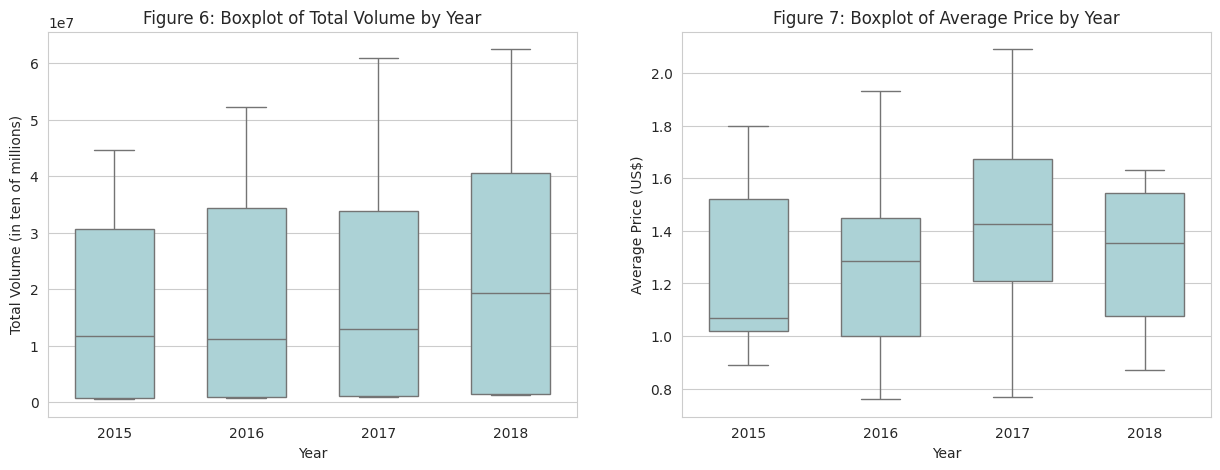

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(ax=axes[0], data=df_totalus, y='Total Volume', x='year', color='#A5D8DD', width=0.6)
axes[0].set_title('Figure 6: Boxplot of Total Volume by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Volume (in ten of millions)')

sns.boxplot(ax=axes[1], data=df_totalus, y='AveragePrice', x='year', color='#A5D8DD', width=0.6)
axes[1].set_title('Figure 7: Boxplot of Average Price by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Price (US$)')
plt.show()

Observations:
- When we look at a more specific dataset (in this case, only aggregate data at the country level), there are no outliers.
- What seems to be an outlier problem previously when we look at the "composite" dataset (which includes rows of data that are aggregated at different levels) turns out to be the problem with data compliation.
- While the boxplots indicates no outliers, the boxplot for total volume looks a bit unnatural in that their lower portions are sticked to the x-axis, indicating many low values in the dataset.
- Next, we explore the last dimension (product type) to see if we can discover anything new. We do that by ploting the boxplots which are splited by the product type.

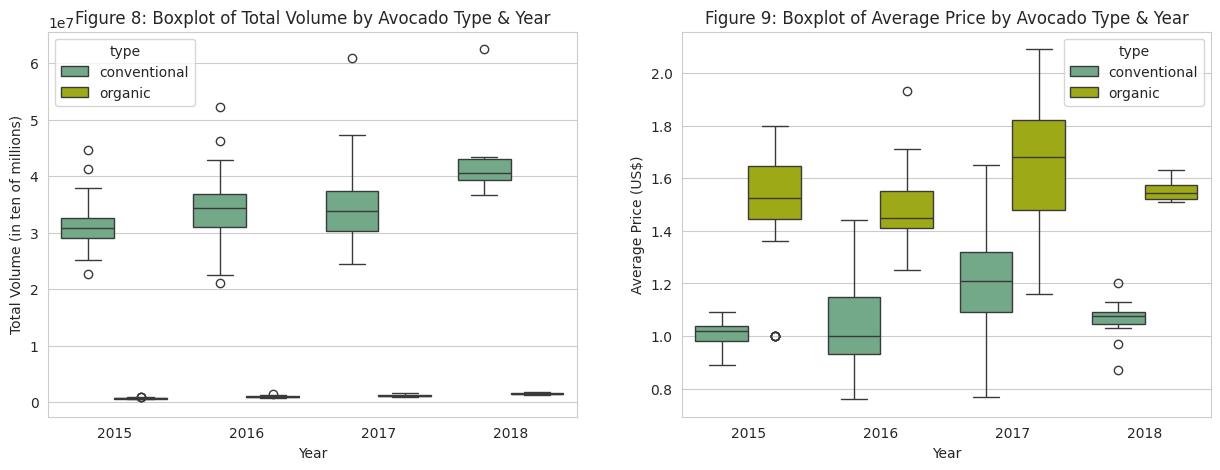

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(ax=axes[0], data=df_totalus, y='Total Volume', x='year', hue='type', palette=['#6AB187', '#B3C100'])
axes[0].set_title('Figure 8: Boxplot of Total Volume by Avocado Type & Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Volume (in ten of millions)')

sns.boxplot(ax=axes[1], data=df_totalus, y='AveragePrice', x='year', hue='type', palette=['#6AB187', '#B3C100'])
axes[1].set_title('Figure 9: Boxplot of Average Price by Avocado Type & Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Price (US$)')
plt.show()

Obversations:
- It is clear that total volumes are remarkably different between organic avocados and conventional avocados. Sales volumnes of organic avocados were just a small fraction of those of conventional avocados over the periods shown.
- In addition, organic avocados were more expensive than conventional avocados.
- There are some potential outliers in both the prices and volumes in some years. Because of the insignificant number of potential outliers, my lack of domain knowledge to judge if the values are outliers, and the educational purpose of this exercise, I decided not to remove them.
- Since, the boxplot of total volume does not show data from organic avocados clearly, I created two separated boxplots of total volumes for two types of avocados. I also developed boxplots for the volumes of the two major avocado PLU 4046 and PLU 4225.

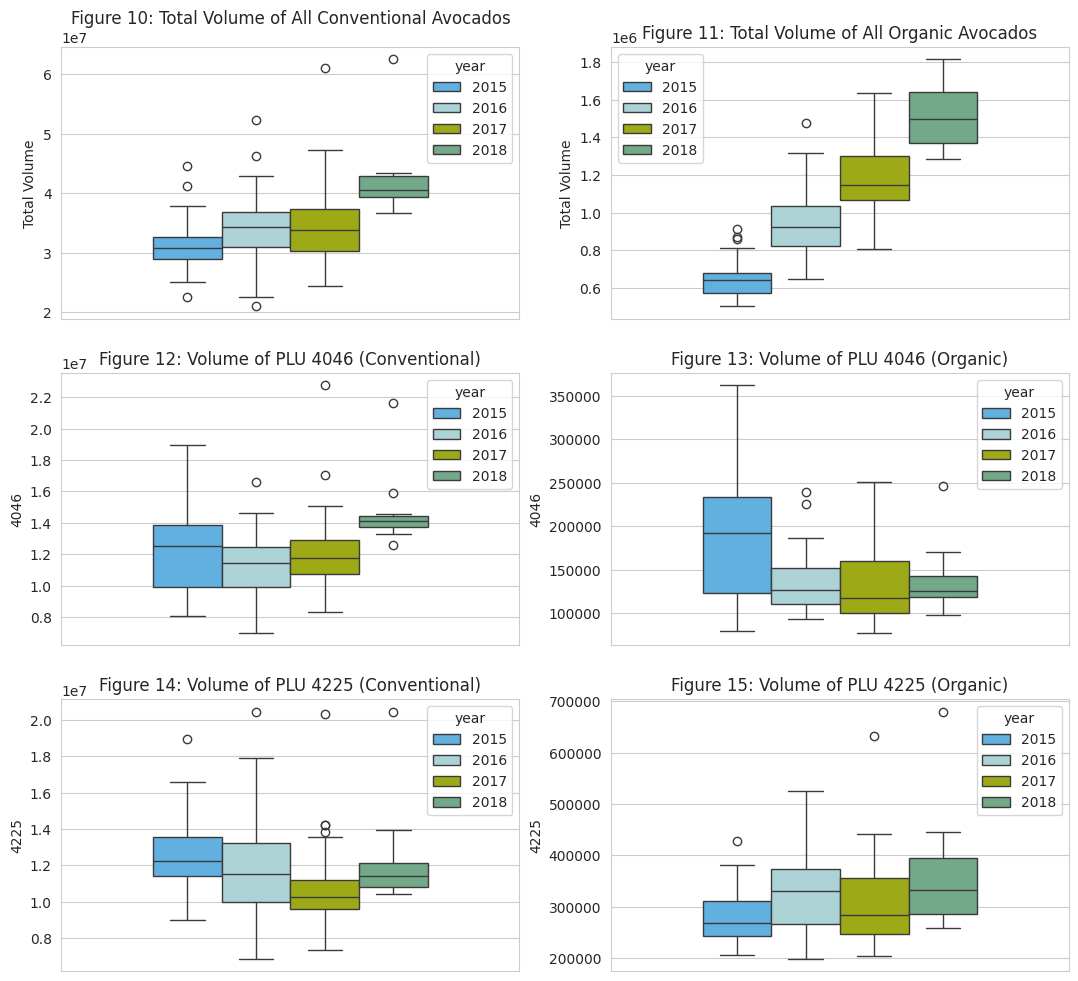

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(13, 12))
# Boxplot of Total Volume of All Conventional Avocados
sns.boxplot(ax=axes[0][0], data=df_totalus[df_totalus['type']=='conventional'], y='Total Volume', hue='year', palette=['#4CB5F5', '#A5D8DD', '#B3C100', '#6AB187'], width=0.6, dodge=True)
axes[0][0].set_title('Figure 10: Total Volume of All Conventional Avocados')

# Boxplot of Total Volume of All Organic Avocados
sns.boxplot(ax=axes[0][1], data=df_totalus[df_totalus['type']=='organic'], y='Total Volume', hue='year', palette=['#4CB5F5', '#A5D8DD', '#B3C100', '#6AB187'], width=0.6, dodge=True)
axes[0][1].set_title('Figure 11: Total Volume of All Organic Avocados')

# Boxplot of Volume of PLU 4046-Conventional
sns.boxplot(ax=axes[1][0],  data=df_totalus[df_totalus['type']=='conventional'], y='4046', hue='year', palette=['#4CB5F5', '#A5D8DD', '#B3C100', '#6AB187'], width=0.6, dodge=True)
axes[1][0].set_title('Figure 12: Volume of PLU 4046 (Conventional)')

# Boxplot of Volume of PLU 4046 Organic
sns.boxplot(ax=axes[1][1], data=df_totalus[df_totalus['type']=='organic'], y='4046', hue='year', palette=['#4CB5F5', '#A5D8DD', '#B3C100', '#6AB187'], width=0.6, dodge=True)
axes[1][1].set_title('Figure 13: Volume of PLU 4046 (Organic)')

# Boxplot of Volume of PLU 4225 - Conventional
sns.boxplot(ax=axes[2][0], data=df_totalus[df_totalus['type']=='conventional'], y='4225', hue='year', palette=['#4CB5F5', '#A5D8DD', '#B3C100', '#6AB187'], width=0.6, dodge=True)
axes[2][0].set_title('Figure 14: Volume of PLU 4225 (Conventional)')

# Boxplot of Volume of PLU 4225 Organic
sns.boxplot(ax=axes[2][1], data=df_totalus[df_totalus['type']=='organic'], y='4225', hue='year', palette=['#4CB5F5', '#A5D8DD', '#B3C100', '#6AB187'], width=0.6, dodge=True)
axes[2][1].set_title('Figure 15: Volume of PLU 4225 (Organic)')


plt.show()

### 4. Categorical Features
- The dataset has  four categorical features: product type (organic vs conventional), year, month, and region.
- We will explore the frequencies of these categorical data

In [ ]:
# number of months the data are available for each year

months_with_data= df_totalus.groupby('year')['month'].nunique().reset_index()
months_with_data

# the number of distinct cities and regions
geographic_area = df.groupby('region_group')['region'].nunique().reset_index()

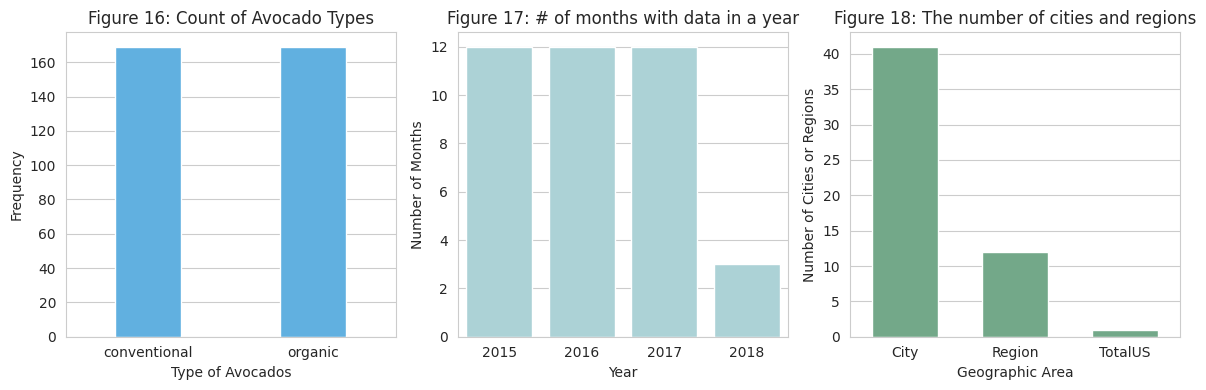

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))
sns.countplot(ax=axes[0], data=df_totalus, x='type', color='#4CB5F5', width=0.4)
axes[0].set_title('Figure 16: Count of Avocado Types')
axes[0].set_xlabel('Type of Avocados')
axes[0].set_ylabel('Frequency')

sns.barplot(ax=axes[1], data=months_with_data, x='year', y='month', color='#A5D8DD')
axes[1].set_title('Figure 17: # of months with data in a year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Months')

sns.barplot(ax=axes[2], data=geographic_area, x='region_group', y='region', color='#6AB187', width=0.6)
axes[2].set_title('Figure 18: The number of cities and regions')
axes[2].set_xlabel('Geographic Area')
axes[2].set_ylabel('Number of Cities or Regions')

plt.tight_layout()
plt.show()

Observations:
- There is equal amount of data for organic avocados and conventional avocados
- Years 2016-2017 have data for the entire year while there are data for only three months in 2018. We will do analysis for 2015-2017, particulary with seasonal analysis.
- There are separate data for 41 cities grouped into 12 regions, and for the entire country.


### 5. Univariate Analysis
- We will explore the distribution of the quantitaive features in this section.
- We will develop histograms for average prices and volumes
- The value range of organic and conventional avocados are distict and only available for three months in 2018. Therefore, we create  and use two separate dataframe for the two types of avocados in three years from 2015 to 2017 in subsequent analyses.

In [ ]:
# dataset for conventional avocados
df_demand_conventional = df_totalus[(df_totalus['year'].isin([2015,2016, 2017])) & (df_totalus['type']=='conventional')]
# dataset for organic avocados
df_demand_organic = df_totalus[(df_totalus['year'].isin([2015,2016, 2017])) & (df_totalus['type']=='organic')]

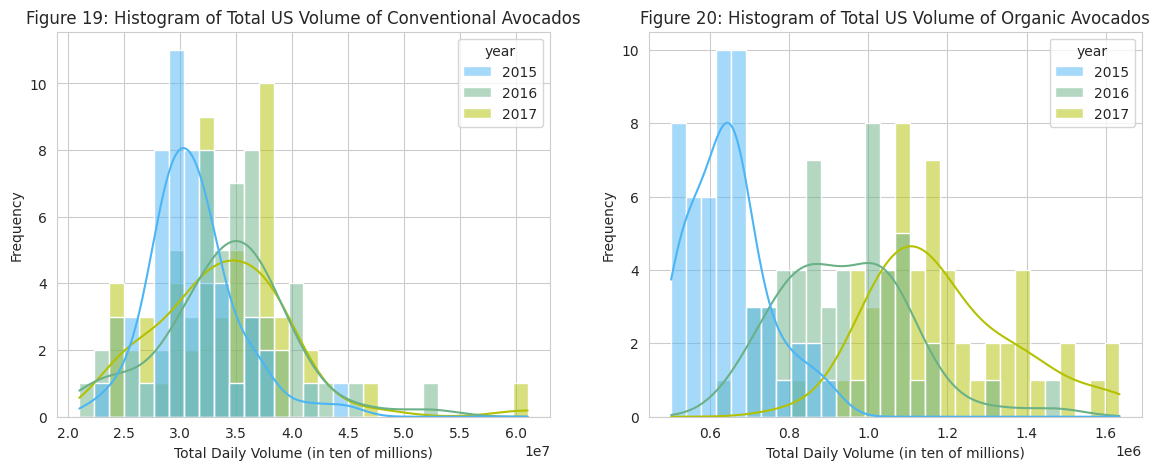

In [ ]:
# Histogram of Total US Consumption of Conventional Avocados
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(ax=axes[0], data=df_demand_conventional, x='Total Volume', bins=30, kde=True, hue='year', palette=['#4CB5F5', '#6AB187', '#B3C100'])
axes[0].set_title('Figure 19: Histogram of Total US Volume of Conventional Avocados')
axes[0].set_ylabel('Frequency')
axes[0].set_xlabel('Total Daily Volume (in ten of millions)')

# Histogram of Total US Consumption of Organic Avocados
sns.histplot(ax=axes[1], data=df_demand_organic, x='Total Volume', bins=30, kde=True, hue='year', palette=['#4CB5F5', '#6AB187', '#B3C100'])
axes[1].set_title('Figure 20: Histogram of Total US Volume of Organic Avocados')
axes[1].set_ylabel('Frequency')
axes[1].set_xlabel('Total Daily Volume (in ten of millions)')
plt.show()

In [ ]:
average_consumption_conventional = df_demand_conventional['Total Volume'].mean().round(2)
average_consumption_organic = df_demand_organic['Total Volume'].mean().round(2)
print(f"Average consumption of conventional avocados in the US: {average_consumption_conventional}")
print(f"Average consumption of organic avocados in the US: {average_consumption_organic}")

Average consumption of conventional avocados in the US: 33093727.3
Average consumption of organic avocados in the US: 926068.42


Observations:
- We can see the volume distribution of conventional over three year period is about normal but slight skewed to the right. The average daily consumption of avocados in the US was about 33 million avocados. The typical range was between 28 to 38 million avocados. In some rare days the demand exceeded 50 million.
- The demand for conventional avocados was very similar in 2016 and 2017 while the 2015 demand was lower.

- Organic avocodos were consumed much less than conventional avocados, with the average daily consumption was about 930,000 avocados. The organic volume distribution are multimodal over the three years period, indicating significant change in the consumption over that period. Yearly consumption were higher in year on year.

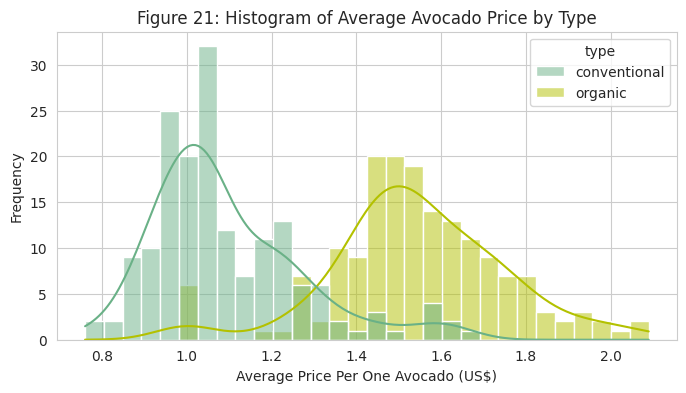

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df_totalus, x='AveragePrice', bins=30, kde=True, color='orange', hue='type', palette=['#6AB187', '#B3C100'])
plt.title('Figure 21: Histogram of Average Avocado Price by Type')
plt.xlabel('Average Price Per One Avocado (US$)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
average_conventional_price = df_demand_conventional['AveragePrice'].mean().round(2)
average_organic_price = df_demand_organic['AveragePrice'].mean().round(2)
print(f"Average price of conventional avocados in the US: {average_conventional_price}")
print(f"Average price of organic avocados in the US: {average_organic_price}")

Average price of conventional avocados in the US: 1.09
Average price of organic avocados in the US: 1.55


Observations:
- We can see the price distributions are slightly skwed to the right. Organic avocados were 50% more expensive than conventional avocados.
- The average price of one conventional avocado was about USD1  compared to
 USD1.5 for one organic avocado

### 6. Bivariate Analysis
- We explore the changes of volumes and price over time for the two kinds of avocados
- We also examine whether the demand for avocados varied in different time of a year


### 6.1. Volumes and Prices by Categorical Features

   year          type  Total Volume  AveragePrice
0  2015  conventional   31224729.15          1.01
1  2015       organic     645563.57          1.50
2  2016  conventional   34043449.79          1.05
3  2016       organic     940379.88          1.48
4  2017  conventional   33995658.14          1.22
5  2017       organic    1187239.29          1.65
6  2018  conventional   42125533.35          1.06
7  2018       organic    1510487.83          1.55


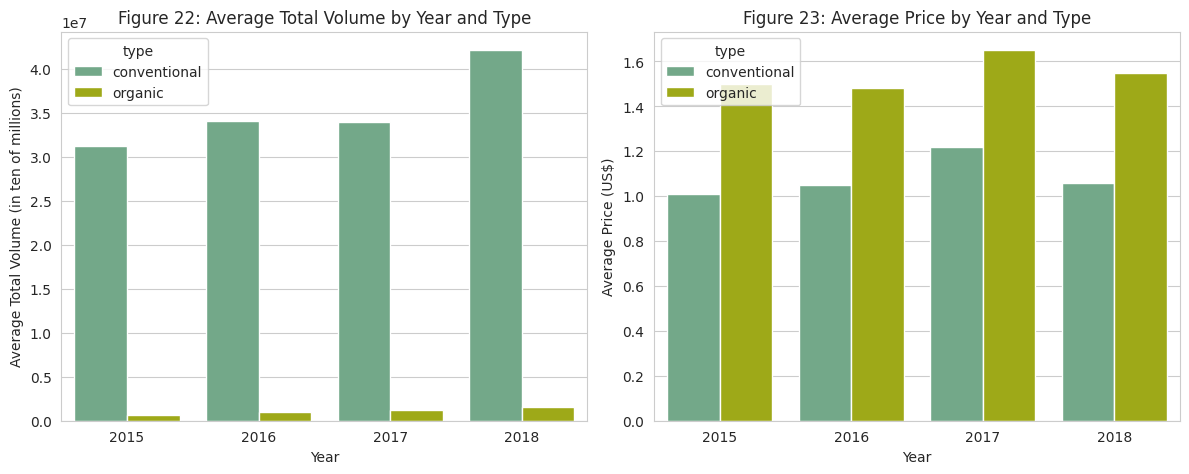

In [ ]:
# create a pivot table to show volumes and prices at different years for the two kinds of avocados
grouped_df = df_totalus.groupby(['year', 'type'])[['Total Volume', 'AveragePrice']].mean().round(2).reset_index()
print(grouped_df)

# Create bar plots to display the information
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Total Volume Bar Plot
sns.barplot(ax=axes[0], data=grouped_df, x='year', y='Total Volume', hue='type', palette=['#6AB187', '#B3C100'])
axes[0].set_title('Figure 22: Average Total Volume by Year and Type')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Average Total Volume (in ten of millions)')

# Average Price Bar Plot
sns.barplot(ax=axes[1], data=grouped_df, x='year', y='AveragePrice', hue='type', palette=['#6AB187', '#B3C100'])
axes[1].set_title('Figure 23: Average Price by Year and Type')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Price (US$)')

plt.tight_layout()
plt.show()

- The charts above reveal the same insights that we discussed in the previous section in a much clearer way.

### 6.2. Volumes and Prices by Region in a Specific Year 2016 and Conventional Avocados

In [ ]:
# create a dataset for conventional avocados in 2016
df_2016 = df_region[(df_region['year']==2016)&(df_region['type']=='conventional')].groupby(['region'])[['Total Volume', 'AveragePrice']].mean().round(2).reset_index()

# Sort Total Volume (desc), Price (asc)
df_2016 = df_2016.sort_values(by=['Total Volume', 'AveragePrice'], ascending=[False, True])


print(df_2016)

                 region  Total Volume  AveragePrice
10                 West    6404891.89          0.92
1            California    6105539.33          1.05
8          SouthCentral    5730807.44          0.86
4             Northeast    4104208.70          1.32
9             Southeast    3752283.78          1.07
2            GreatLakes    3295252.70          1.14
3              Midsouth    2866148.51          1.19
6                Plains    1784317.44          1.13
11     WestTexNewMexico     824285.77          0.85
0   BaltimoreWashington     768130.30          1.36
5    NorthernNewEngland     415320.93          1.23
7         SouthCarolina     350796.14          1.08


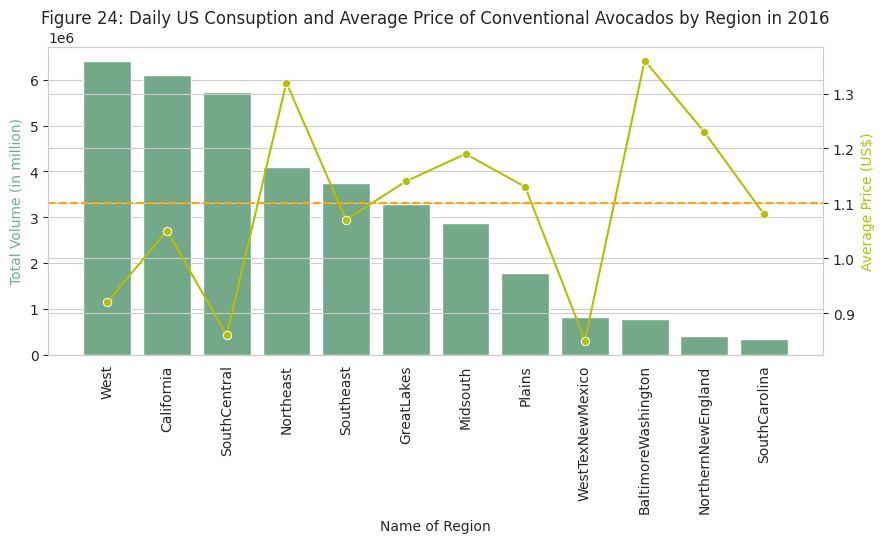

In [ ]:
# Create figure and axis
fig, ax1 = plt.subplots(figsize=(10, 4))

# Bar plot for Total Volume (Primary y-axis)
sns.barplot(ax=ax1, data=df_2016, x='region', y='Total Volume', errorbar=None, color='#6AB187')

# Rotate x-axis labels
ax1.set_xticks(ax1.get_xticks())
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)

# Create a secondary y-axis
ax2 = ax1.twinx()

# Line plot for Average Price (Secondary y-axis)
sns.lineplot(ax=ax2, data=df_2016, x='region', y='AveragePrice', color='#B3C100', marker='o', errorbar=None)

# Line plot for the average horizontal line
ax2.axhline(y=df_2016['AveragePrice'].mean(), color='orange', linestyle='--')

# Set labels
ax1.set_ylabel("Total Volume (in million)", color='#6AB187')
ax2.set_ylabel("Average Price (US$)", color='#B3C100')
ax1.set_title('Figure 24: Daily US Consuption and Average Price of Conventional Avocados by Region in 2016')
ax1.set_xlabel('Name of Region')

plt.show()

Observations:
- In 2016, the west region had the highest daily consumption of conventional avocados with more than 60 million avocados, follwed by California and South Central region. The South Carolina region had the lowest level of consumption.
- In term of prices, conventional avocados were most expensive in the areas in Baltimore and Washington, while they were cheapeast in West Texas and New Mexico, and South Central.
- The average price per one avocado across all regions was $1.1. Avocados were more expensive than the cross-region average price in six regions, including North East, Great Lakes, Mid South, Plains, Baltimore+Washington, and Northen New England.

### 6.3. Seasonality of Avocado Demands

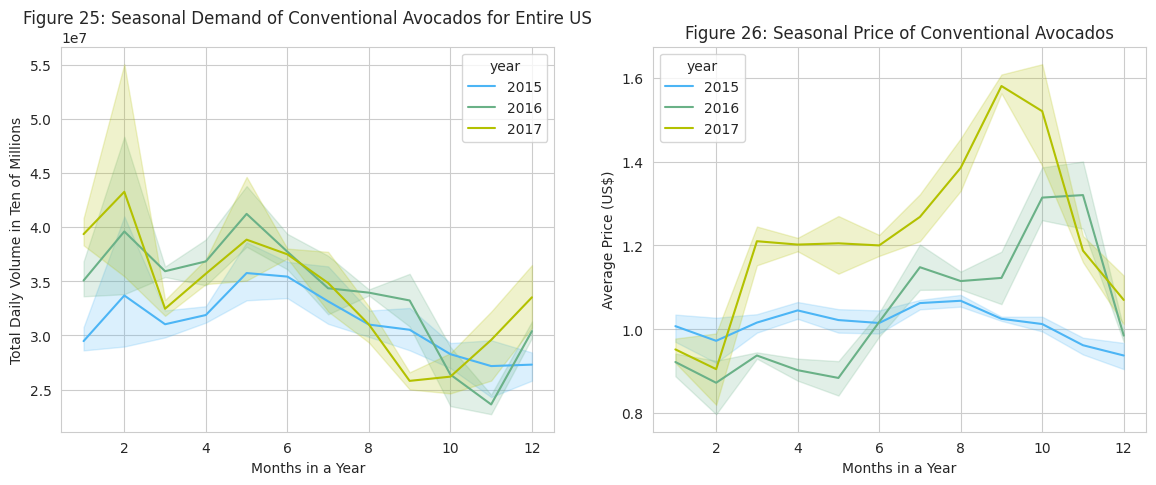

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(ax=axes[0], data=df_demand_conventional, x='month', y='Total Volume', hue='year', palette=['#4CB5F5', '#6AB187', '#B3C100'])
axes[0].set_title('Figure 25: Seasonal Demand of Conventional Avocados for Entire US')
axes[0].set_xlabel('Months in a Year')
axes[0].set_ylabel('Total Daily Volume in Ten of Millions')

sns.lineplot(ax=axes[1], data=df_demand_conventional, x='month', y='AveragePrice', hue='year', palette=['#4CB5F5', '#6AB187', '#B3C100'])
axes[1].set_title('Figure 26: Seasonal Price of Conventional Avocados')
axes[1].set_xlabel('Months in a Year')
axes[1].set_ylabel('Average Price (US$)')
plt.show()

Observations:
- We see a similar pattern of monthly movements in each of the years
- Demand for conventional avocados fluctuated in the first half of the year, then droped continuosly between June to November and picked up again in December.
- Prices were lowest in Feb, picked up in March and remained quite stable between March and May. Increased during June and reached a peak during August and October and then droped siginificantly.

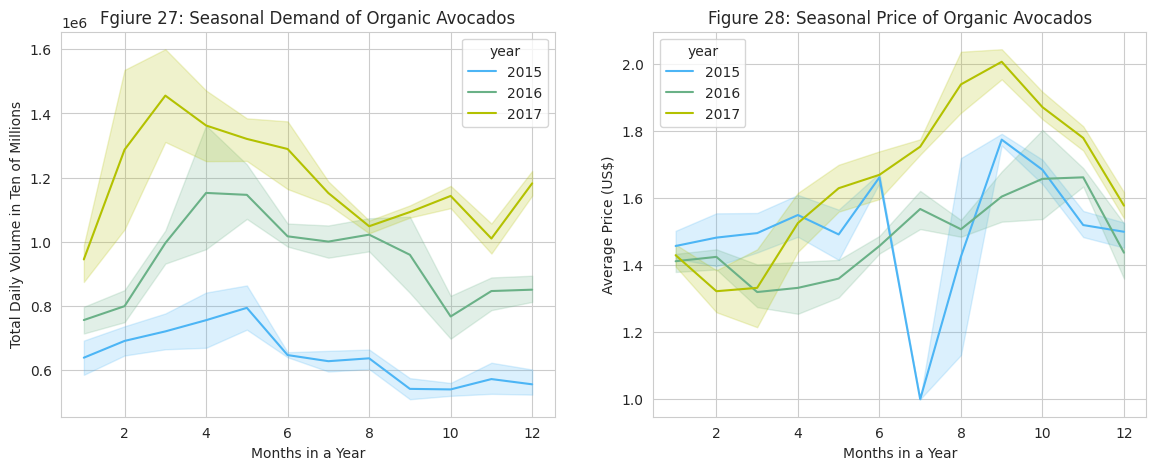

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(ax=axes[0], data=df_demand_organic, x='month', y='Total Volume', hue='year', palette=['#4CB5F5', '#6AB187', '#B3C100'])
axes[0].set_title('Fgiure 27: Seasonal Demand of Organic Avocados')
axes[0].set_xlabel('Months in a Year')
axes[0].set_ylabel('Total Daily Volume in Ten of Millions')

sns.lineplot(ax=axes[1], data=df_demand_organic, x='month', y='AveragePrice', hue='year', palette=['#4CB5F5', '#6AB187', '#B3C100'])
axes[1].set_title('Figure 28: Seasonal Price of Organic Avocados')
axes[1].set_xlabel('Months in a Year')
axes[1].set_ylabel('Average Price (US$)')
plt.show()

Observations:
- The demand for organic avocados increased over year month by month. Demands increased at the beginning of the years, reaching a peak between March and May depending on years, then dropped quickly until October.
- Except for 2015, prices of avocados moved in the opposite directios as compared to volume, which is understandable. Prices were lowest March when the demands were highest. Then they increased over the months and hit a peak around September or October and fell again.

### 6.4 Relationship between Volume and Price
- We explore the relationship between volume and price in this part
- We develop scatter plots between price and volume to examine possible relationship between these two features


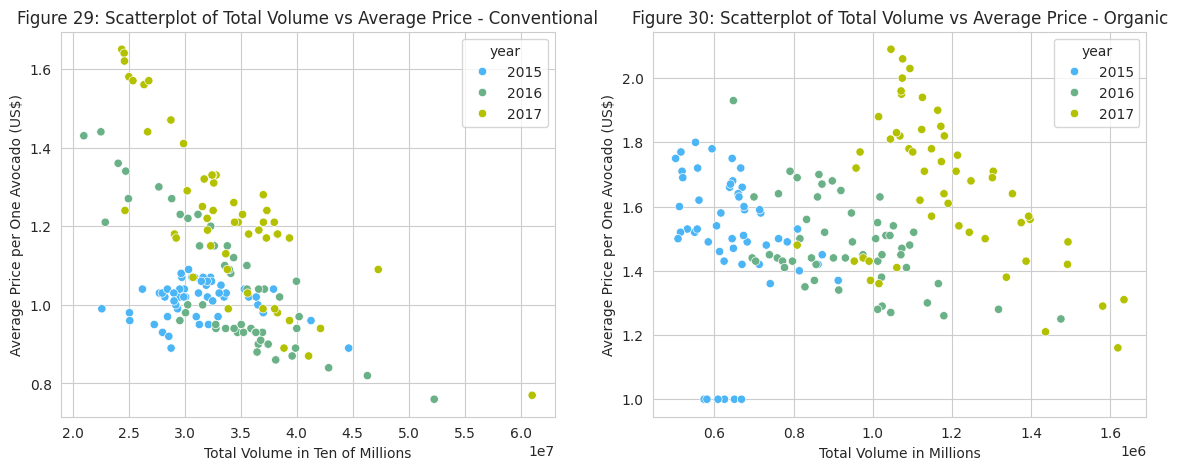

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(ax=axes[0], data=df_demand_conventional, x='Total Volume', y='AveragePrice', hue='year', palette=['#4CB5F5', '#6AB187', '#B3C100'])
axes[0].set_title('Figure 29: Scatterplot of Total Volume vs Average Price - Conventional')
axes[0].set_xlabel('Total Volume in Ten of Millions')
axes[0].set_ylabel('Average Price per One Avocado (US$)')
sns.scatterplot(ax=axes[1], data=df_demand_organic, x='Total Volume', y='AveragePrice', hue='year', palette=['#4CB5F5', '#6AB187', '#B3C100'])
axes[1].set_title('Figure 30: Scatterplot of Total Volume vs Average Price - Organic')
axes[1].set_xlabel('Total Volume in Millions')
axes[1].set_ylabel('Average Price per One Avocado (US$)')
plt.show()

Obvervations:
- The scatter plots show there was a negatively correlated relationship between price and volume for both conventional and organic avocatos.

- These relationships are clearer when we look at separate clusters of data for each year separately.

- US customers for conventional avocados seemed to be more price-sensitive than those for organic avocados.



**Linear Model Plots**
- We use linear model plots to examine the relationship between price and volume more closely.
- The linear model plots add the trend line on top of the scatter plots to show the relationship more visually

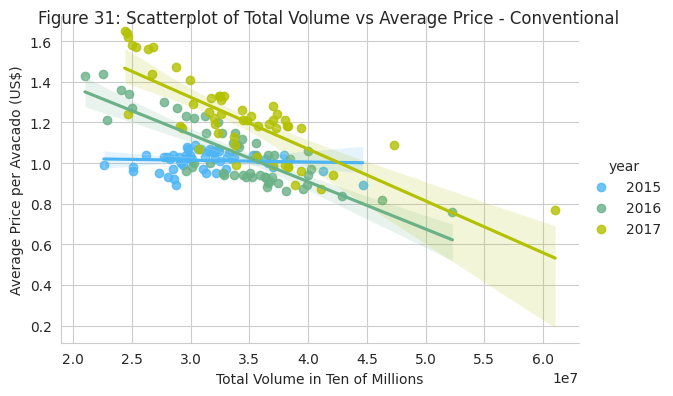

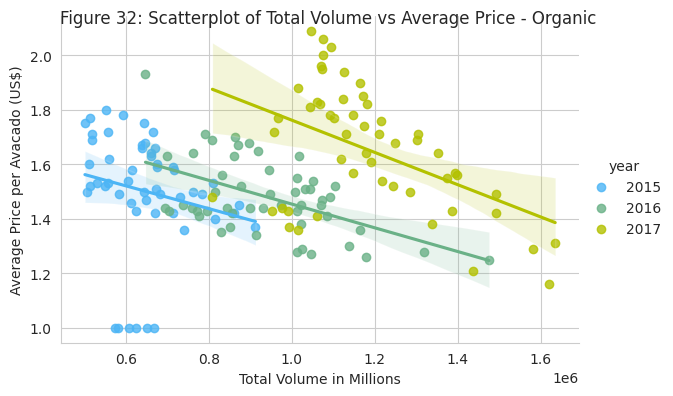

In [ ]:
# Create the first lmplot
g1 = sns.lmplot(data=df_demand_conventional, x='Total Volume', y='AveragePrice', hue='year', height=4, aspect=1.5, palette=['#4CB5F5', '#6AB187', '#B3C100'])
g1.fig.suptitle('Figure 31: Scatterplot of Total Volume vs Average Price - Conventional')
g1.set_axis_labels('Total Volume in Ten of Millions', 'Average Price per Avacado (US$)')

# Create the second lmplot
g2 = sns.lmplot(df_demand_organic, x='Total Volume', y='AveragePrice', hue='year', height=4, aspect=1.5, palette=['#4CB5F5', '#6AB187', '#B3C100'])
g2.set_axis_labels('Total Volume in Millions', 'Average Price per Avacado (US$)')

g2.fig.suptitle('Figure 32: Scatterplot of Total Volume vs Average Price - Organic')

plt.show()

Observations
- Price of conventional avocados in 2015 fairly stable across different levels of volumes while prices were negatively correlated with volumes in both 2016 and 2017.

- Demand curve shifted to the right between 2016 and 2017, meaning more conventional avocodos were consumed at the same price point in 2017 than in 2016.

- We can see in the second chart that relationship between price and volume of organic avocados followed the same pattern in three years. Demand curves for organic avocaos shifted right year on year, indicating growth in demand.

### 6.5 Correlation Heatmap

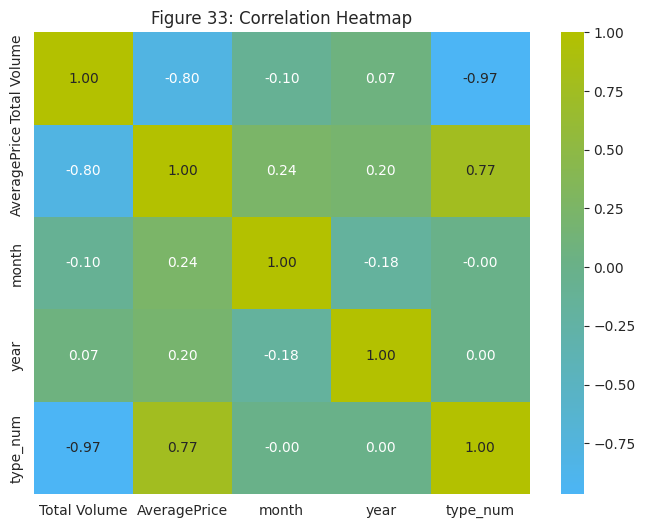

In [ ]:
# Subset the numeric columns of interest
numeric_cols = ['Total Volume', 'AveragePrice', 'month', 'year', 'type_num']
df_totalus_subset = df_totalus.copy()

# create a new column to convert type to numeric value 0, 1
df_totalus_subset['type_num'] = df_totalus_subset['type'].map({'conventional': 0, 'organic': 1})

# Create a correlation matrix
corr_matrix = df_totalus_subset[numeric_cols].corr()

# define custom color map
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list("custom", ['#4CB5F5', '#6AB187', '#B3C100'])

# plot the headmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap=custom_cmap, fmt='.2f')
plt.title('Figure 33: Correlation Heatmap')
plt.show()

Observations:
- volume is negatively correlated fairly strongly with price.
- the avocado type is strongly positively correlated with average price, while  it is strongly negatively correlated with volume.
- average price has a weak correlation with average price.
- year and month have no correlation with avocado type.


### 7. Conclusion
In this notebook, we have:
- loaded the avocado dataset into Pandas DataFrame
- discovered that there was no issue with missing values
- checked potential outliers with a series of boxplots
- discovered that the dataset includes both individual city's data and aggregate data at regional and country levels
- encoded the region features into three categories - city, region, country and developed three separate datasets for each futher analysis
- explored univariate distributions of price and volume
- explored bivariate relationship between price **and** volume
- explored bivariate relationship between price, volume **and** time (seasonality), avocados type, using bar plots, line plots, scatter plots, linear model plots, and heat map.

Graphs as required by the lab are:
- Figure 16
- Figure 5
- Figure 9
- Figure 21
